# Analisis Dataset Skincare - Multiple Brands

Notebook ini memuat dataset skincare dari **8 file Excel** (satu per brand) dan menggabungkannya menjadi satu dataset.

**File Excel yang dibutuhkan:**
- avoskin.xlsx
- emina.xlsx
- glad2glow.xlsx
- scarlett.xlsx
- somethinc.xlsx
- originote.xlsx
- wardah.xlsx
- whitelab.xlsx

**Kolom yang diharapkan:** product_name, product_type, active_ingredients, skin_type, benefits

In [15]:
import os
import pandas as pd

# Daftar file Excel
excel_files = ['avoskin.xlsx', 'emina.xlsx', 'glad2glow.xlsx', 'scarlett.xlsx', 
               'somethinc.xlsx', 'originote.xlsx', 'wardah.xlsx', 'whitelab.xlsx']

# Load dan gabung semua file
all_dfs = []
for filename in excel_files:
    if os.path.exists(filename):
        try:
            df_temp = pd.read_excel(filename)
            df_temp['brand'] = filename.replace('.xlsx', '')
            all_dfs.append(df_temp)
            print(f'✅ {filename}: {len(df_temp)} baris')
        except Exception as e:
            print(f'❌ {filename}: {e}')
    else:
        print(f'⚠️  {filename}: Tidak ditemukan')

# Gabung semua dataframe
if all_dfs:
    df = pd.concat(all_dfs, ignore_index=True)
    print(f'\n✅ Total: {len(df):,} baris dari {len(all_dfs)} brand')
else:
    raise FileNotFoundError('Tidak ada file Excel yang berhasil dimuat!')

✅ avoskin.xlsx: 30 baris
✅ emina.xlsx: 30 baris
✅ glad2glow.xlsx: 25 baris
✅ scarlett.xlsx: 25 baris
✅ somethinc.xlsx: 25 baris
✅ originote.xlsx: 25 baris
✅ wardah.xlsx: 30 baris
✅ whitelab.xlsx: 25 baris

✅ Total: 215 baris dari 8 brand
✅ somethinc.xlsx: 25 baris
✅ originote.xlsx: 25 baris
✅ wardah.xlsx: 30 baris
✅ whitelab.xlsx: 25 baris

✅ Total: 215 baris dari 8 brand


In [2]:
# Eksplorasi Dataset
print('=' * 80)
print('📊 EKSPLORASI DATASET GABUNGAN')
print('=' * 80)

# Preview data
print('\n5 Baris Pertama:')
display(df.head(5))

# Info struktur
print('\n' + '─' * 80)
print('Struktur Dataset:')
df.info()

# Ringkasan per brand
print('\n' + '─' * 80)
print('Distribusi per Brand:')
for brand, count in df['brand'].value_counts().sort_index().items():
    print(f'  {brand:<15} : {count:>4,} produk')
print(f'  {"─" * 28}')
print(f'  {"TOTAL":<15} : {len(df):>4,} produk')
print('=' * 80)

📊 EKSPLORASI DATASET GABUNGAN

5 Baris Pertama:


,product_name,product_type,active_ingredients,skin_type,benefits,brand
0,Avoskin Your Skin Bae Vitamin C 3% + Niacinami...,Serum,"Aqua, Glycerin, 3-O-Ethyl Ascorbic Acid, Butyl...","Semua Jenis Kulit, \nKusam",Mencerahkan kulit secara efektif\nMenyamarkan ...,avoskin
1,Avoskin Ultra Brightening Cream,Moisturizer,"Alpha-Arbutin, Retinol, BHA, Glycyrrhiza Urale...","Kulit normal. kulit kusam, menua, berjerawat r...",berfungsi untuk membantu melawan tampilan kusa...,avoskin
2,Avoskin Your Skin Bae Alpha Arbutin + Grapesee...,Serum,"Alpha-Arbutin, Ananas Sativus (Pineapple) Frui...","kusam, sensitif, normal, kombinasi",mencerahkan kulit dan menjaga kulit tetap seha...,avoskin
3,Avoskin Your Skin Bae Niacinamide 12% + Centel...,Serum,"Niacinamide, Glycerin, Butylene Glycol, Biosac...","Sensitif, kering, kusam","menjaga kulit cerah maksimal, terhidrasi, terh...",avoskin
4,Avoskin Intensive Nourishing Eye Cream\n,Eye cream,"Ethylhexyl Olivate, PEG-4 Olivate, Phytosteryl...","kering, sensitif, kusam",Melembapkan kulit di sekitar mata sehingga dap...,avoskin



────────────────────────────────────────────────────────────────────────────────
Struktur Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   product_name        215 non-null    object
 1   product_type        215 non-null    object
 2   active_ingredients  215 non-null    object
 3   skin_type           215 non-null    object
 4   benefits            215 non-null    object
 5   brand               215 non-null    object
dtypes: object(6)
memory usage: 10.2+ KB

────────────────────────────────────────────────────────────────────────────────
Distribusi per Brand:
  avoskin         :   30 produk
  emina           :   30 produk
  glad2glow       :   25 produk
  originote       :   25 produk
  scarlett        :   25 produk
  somethinc       :   25 produk
  wardah          :   30 produk
  whitelab        :   25 produk
  ─────────

In [16]:

import pandas as pd

main_cols = ['product_name', 'active_ingredients', 'benefits']

print('PEMBERSIHAN DATA')
print('-' * 50)
print(f'Kolom utama: {main_cols}\n')

# Validasi kolom
missing_cols = [col for col in main_cols if col not in df.columns]
if missing_cols:
    print(f'Kolom tidak ditemukan: {missing_cols}')
    print(f'Kolom tersedia: {list(df.columns)}')
    print('\nSesuaikan nama kolom di main_cols')
else:
    before = len(df)

    print('Missing values:')
    missing_info = df[main_cols].isnull().sum()
    if missing_info.sum() > 0:
        for col, count in missing_info.items():
            if count > 0:
                print(f'   {col}: {count} ({count/before*100:.1f}%)')
    else:
        print(' Tidak ada missing values')
    

    df = df.dropna(subset=main_cols)
    after = len(df)
    removed = before - after
    

    print(f'\nSebelum : {before:,} baris')
    print(f'Sesudah : {after:,} baris')
    print(f'Dihapus : {removed:,} ({removed/before*100:.1f}%)')

    print('\n5 Baris Pertama (Setelah Pembersihan):')
    display(df.head(5))
    
    print('\nStruktur Dataset:')
    df.info()
    

    if 'brand' in df.columns:
        print('\nRingkasan per Brand:')
        for brand, count in df['brand'].value_counts().sort_index().items():
            print(f'  {brand:<15} : {count:,} produk')
        print(f'  TOTAL{" "*10} : {len(df):,} produk')
    
    print(f'\nPEMBERSIHAN SELESAI - {len(df):,} produk siap diproses')
    print('Selanjutnya: Text preprocessing (cleaning & stemming)')

PEMBERSIHAN DATA
--------------------------------------------------
Kolom utama: ['product_name', 'active_ingredients', 'benefits']

Missing values:
 Tidak ada missing values

Sebelum : 215 baris
Sesudah : 215 baris
Dihapus : 0 (0.0%)

5 Baris Pertama (Setelah Pembersihan):


,product_name,product_type,active_ingredients,skin_type,benefits,brand
0,Avoskin Your Skin Bae Vitamin C 3% + Niacinami...,Serum,"Aqua, Glycerin, 3-O-Ethyl Ascorbic Acid, Butyl...","Semua Jenis Kulit, \nKusam",Mencerahkan kulit secara efektif\nMenyamarkan ...,avoskin
1,Avoskin Ultra Brightening Cream,Moisturizer,"Alpha-Arbutin, Retinol, BHA, Glycyrrhiza Urale...","Kulit normal. kulit kusam, menua, berjerawat r...",berfungsi untuk membantu melawan tampilan kusa...,avoskin
2,Avoskin Your Skin Bae Alpha Arbutin + Grapesee...,Serum,"Alpha-Arbutin, Ananas Sativus (Pineapple) Frui...","kusam, sensitif, normal, kombinasi",mencerahkan kulit dan menjaga kulit tetap seha...,avoskin
3,Avoskin Your Skin Bae Niacinamide 12% + Centel...,Serum,"Niacinamide, Glycerin, Butylene Glycol, Biosac...","Sensitif, kering, kusam","menjaga kulit cerah maksimal, terhidrasi, terh...",avoskin
4,Avoskin Intensive Nourishing Eye Cream\n,Eye cream,"Ethylhexyl Olivate, PEG-4 Olivate, Phytosteryl...","kering, sensitif, kusam",Melembapkan kulit di sekitar mata sehingga dap...,avoskin



Struktur Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   product_name        215 non-null    object
 1   product_type        215 non-null    object
 2   active_ingredients  215 non-null    object
 3   skin_type           215 non-null    object
 4   benefits            215 non-null    object
 5   brand               215 non-null    object
dtypes: object(6)
memory usage: 10.2+ KB

Ringkasan per Brand:
  avoskin         : 30 produk
  emina           : 30 produk
  glad2glow       : 25 produk
  originote       : 25 produk
  scarlett        : 25 produk
  somethinc       : 25 produk
  wardah          : 30 produk
  whitelab        : 25 produk
  TOTAL           : 215 produk

PEMBERSIHAN SELESAI - 215 produk siap diproses
Selanjutnya: Text preprocessing (cleaning & stemming)


In [17]:
# Text Preprocessing
import re
import pandas as pd
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

print('TEXT PREPROCESSING')
print('-' * 50)

stemmer = StemmerFactory().create_stemmer()

# Fungsi pembersihan
def clean_product_name(text):
    if pd.isna(text): return ''
    text = str(text).lower()
    text = re.sub(r'\d+\s*(ml|g|gr|mg|pcs|pack|sheet|tube|bottle|sachet|lembar)', '', text)
    text = re.sub(r'[^a-z0-9%+\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def clean_active_ingredients(text):
    if pd.isna(text): return ''
    text = str(text).lower()
    text = re.sub(r'\d+\s*(mg|ml|g|gr|gram)\b', '', text)
    text = re.sub(r'[^a-z0-9%+\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def clean_benefits(text):
    if pd.isna(text): return ''
    text = str(text).lower()
    text = re.sub(r'[+&]', ' dan ', text)
    text = re.sub(r'\d+\s*(ml|g|gr|mg|%|pcs|pack)', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

required_cols = ['product_name', 'active_ingredients', 'benefits']
missing = [col for col in required_cols if col not in df.columns]

if missing:
    print(f'Kolom tidak ditemukan: {missing}')
    print(f'Kolom tersedia: {list(df.columns)}')
else:

    print('\nMembersihkan kolom...')
    df['product_name_clean'] = df['product_name'].apply(clean_product_name)
    df['active_ingredients_clean'] = df['active_ingredients'].apply(clean_active_ingredients)
    df['benefits_clean'] = df['benefits'].apply(clean_benefits)
  
    pct_count = df['product_name_clean'].str.contains('%', na=False).sum() + \
                df['active_ingredients_clean'].str.contains('%', na=False).sum()
    if pct_count > 0:
        print(f'Konsentrasi (%) dipertahankan: {pct_count} produk')

    df['text'] = (
        df['product_name_clean'].fillna('') + ' ' +
        df['active_ingredients_clean'].fillna('') + ' ' +
        df['benefits_clean'].fillna('')
    ).str.strip()

    print('Normalisasi & stemming...')
    df['normalized_text'] = df['text'].apply(
        lambda x: re.sub(r'\s+', ' ', re.sub(r'[^a-z\s]', ' ', x if pd.notna(x) else '')).strip()
    )
    df['clean_text'] = df['normalized_text'].apply(lambda x: stemmer.stem(x) if x else '')

    print('\nCONTOH HASIL (3 produk)')
    for i in range(min(3, len(df))):
        brand = f" - {df['brand'].iloc[i].upper()}" if 'brand' in df.columns else ""
        print(f'\nProduk {i+1}{brand}')
        print(f'Original: {df["product_name"].iloc[i][:60]}')
        print(f'Clean   : {df["clean_text"].iloc[i][:70]}')
    
    # Statistik
    word_lengths = df['clean_text'].str.split().str.len()
    print('\nSTATISTIK')
    print(f'Total produk     : {len(df):,}')
    print(f'Text kosong      : {(df["clean_text"] == "").sum()}')
    print(f'Panjang (kata)   : {word_lengths.mean():.0f} rata-rata')
    print(f'Range            : {word_lengths.min():.0f} - {word_lengths.max():.0f}')
    
    print('\nKolom baru: product_name_clean, active_ingredients_clean, benefits_clean,')
    print('            text, normalized_text, clean_text')
  

TEXT PREPROCESSING
--------------------------------------------------

Membersihkan kolom...
Konsentrasi (%) dipertahankan: 29 produk
Normalisasi & stemming...

CONTOH HASIL (3 produk)

Produk 1 - AVOSKIN
Original: Avoskin Your Skin Bae Vitamin C 3% + Niacinamide 2% + Mandar
Clean   : avoskin your skin bae vitamin c niacinamide mandarin orange fruit extr

Produk 2 - AVOSKIN
Original: Avoskin Ultra Brightening Cream
Clean   : avoskin ultra brightening cream alpha arbutin retinol bha glycyrrhiza 

Produk 3 - AVOSKIN
Original: Avoskin Your Skin Bae Alpha Arbutin + Grapeseed Concentrated
Clean   : avoskin your skin bae alpha arbutin grapeseed concentrated serum alpha

STATISTIK
Total produk     : 215
Text kosong      : 0
Panjang (kata)   : 52 rata-rata
Range            : 15 - 150

Kolom baru: product_name_clean, active_ingredients_clean, benefits_clean,
            text, normalized_text, clean_text

CONTOH HASIL (3 produk)

Produk 1 - AVOSKIN
Original: Avoskin Your Skin Bae Vitamin C 3% + 

## 🧠 Representasi Teks dengan Neural Model (TensorFlow)

Mengubah teks menjadi representasi numerik menggunakan Word Embeddings untuk model Deep Learning.

TOKENISASI & ENCODING (TensorFlow)
--------------------------------------------------
Dataset: 215 produk dengan teks valid

Tokenisasi...
Vocabulary: 1,405 kata
Padding sequences...
Shape: (215, 50)

STATISTIK
Vocab size        : 5,000
Max length        : 50
Total kata unik   : 1,405
Panjang sequence  : 51.8 (rata-rata)
Range             : 15 - 150

CONTOH TRANSFORMASI (3 produk)

Produk 1 - AVOSKIN
Text     : avoskin your skin bae vitamin c niacinamide mandarin orange ...
Sequence : [63, 143, 19, 144, 72, 105, 9, 495, 420, 52, 4, 30, 211, 36, 320]...
Padded   : [63, 143, 19, 144, 72, 105, 9, 495, 420, 52, 4, 30, 211, 36, 320]...

Produk 2 - AVOSKIN
Text     : avoskin ultra brightening cream alpha arbutin retinol bha gl...
Sequence : [63, 422, 200, 136, 121, 122, 161, 214, 101, 249, 74, 34, 4, 89, 82]...
Padded   : [63, 422, 200, 136, 121, 122, 161, 214, 101, 249, 74, 34, 4, 89, 82]...

Produk 3 - AVOSKIN
Text     : avoskin your skin bae alpha arbutin grapeseed concentrated s...
Seque

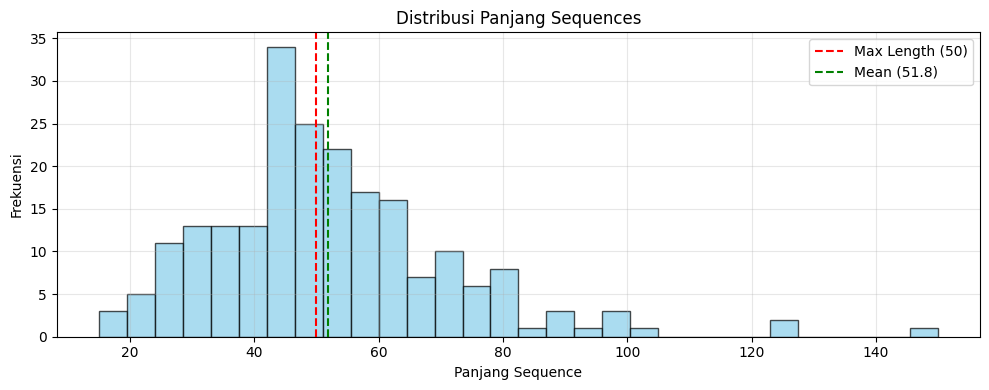


TOKENISASI SELESAI
Variabel tersedia:
   - tokenizer: TensorFlow Tokenizer (vocab_size=5,000)
   - padded: Numpy array (215, 50)
   - word_index: Dict 1,405 kata

Selanjutnya: Buat model Neural Network dengan Embedding Layer


In [18]:
# Representasi Teks dengan TensorFlow
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
import matplotlib.pyplot as plt

print('TOKENISASI & ENCODING (TensorFlow)')
print('-' * 50)

# Validasi kolom
if 'clean_text' not in df.columns:
    print('Kolom "clean_text" tidak ditemukan!')
    print('Jalankan preprocessing terlebih dahulu.')
else:
    # Filter teks valid
    df_valid = df[df['clean_text'].str.strip() != ''].copy()
    texts = df_valid['clean_text'].values.tolist()
    
    print(f'Dataset: {len(df_valid):,} produk dengan teks valid')
    
    # Tokenizer settings
    vocab_size = 5000
    max_length = 50
    oov_token = "<OOV>"
    
    # Inisialisasi dan fit tokenizer
    print('\nTokenisasi...')
    tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_token, lower=False)
    tokenizer.fit_on_texts(texts)
    
    word_index = tokenizer.word_index
    print(f'Vocabulary: {min(vocab_size, len(word_index)):,} kata')
    
    # Convert to sequences
    sequences = tokenizer.texts_to_sequences(texts)
    
    # Padding
    print('Padding sequences...')
    padded = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')
    print(f'Shape: {padded.shape}')
    
    # Statistik
    seq_lengths = [len(seq) for seq in sequences]
    print('\nSTATISTIK')
    print(f'Vocab size        : {vocab_size:,}')
    print(f'Max length        : {max_length}')
    print(f'Total kata unik   : {len(word_index):,}')
    print(f'Panjang sequence  : {np.mean(seq_lengths):.1f} (rata-rata)')
    print(f'Range             : {np.min(seq_lengths)} - {np.max(seq_lengths)}')
    
    # Contoh transformasi
    print('\nCONTOH TRANSFORMASI (3 produk)')
    for i in range(min(3, len(df_valid))):
        brand = f" - {df_valid.iloc[i]['brand'].upper()}" if 'brand' in df_valid.columns else ""
        print(f'\nProduk {i+1}{brand}')
        print(f'Text     : {texts[i][:60]}...')
        print(f'Sequence : {sequences[i][:15]}...')
        print(f'Padded   : {padded[i][:15].tolist()}...')
    
    # Visualisasi distribusi panjang
    print('\nDistribusi Panjang Sequences:')
    plt.figure(figsize=(10, 4))
    plt.hist(seq_lengths, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    plt.axvline(max_length, color='red', linestyle='--', label=f'Max Length ({max_length})')
    plt.axvline(np.mean(seq_lengths), color='green', linestyle='--', label=f'Mean ({np.mean(seq_lengths):.1f})')
    plt.xlabel('Panjang Sequence')
    plt.ylabel('Frekuensi')
    plt.title('Distribusi Panjang Sequences')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Update dataframe
    df = df_valid.copy()
    
    print('\nTOKENISASI SELESAI')
    print('Variabel tersedia:')
    print(f'   - tokenizer: TensorFlow Tokenizer (vocab_size={vocab_size:,})')
    print(f'   - padded: Numpy array {padded.shape}')
    print(f'   - word_index: Dict {len(word_index):,} kata')
    print('\nSelanjutnya: Buat model Neural Network dengan Embedding Layer')

## Neural Network Model - Product Embedding

Membangun model Neural Network untuk mengekstrak representasi embedding dari produk skincare.

In [19]:

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, GlobalAveragePooling1D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

print('NEURAL NETWORK MODEL - PRODUCT EMBEDDING')
print('-' * 50)


embedding_dim = 128
dense_units = 64
dropout_rate = 0.3

print('Hyperparameters:')
print(f'   Vocab Size     : {vocab_size:,}')
print(f'   Max Length     : {max_length}')
print(f'   Embedding Dim  : {embedding_dim}')
print(f'   Dense Units    : {dense_units}')
print(f'   Dropout Rate   : {dropout_rate}')


print('\nBuilding model...')

input_layer = Input(shape=(max_length,), name='input_sequence')

embedding_layer = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    input_length=max_length,
    name='embedding'
)(input_layer)

pooling_layer = GlobalAveragePooling1D(name='global_avg_pool')(embedding_layer)

dense1 = Dense(dense_units, activation='relu', name='dense_1')(pooling_layer)
dropout1 = Dropout(dropout_rate, name='dropout_1')(dense1)

output_layer = Dense(32, activation='relu', name='product_embedding')(dropout1)

model = Model(inputs=input_layer, outputs=output_layer, name='ProductEmbeddingModel')


model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

print('Model created!')

print('\nMODEL ARCHITECTURE')
print('-' * 50)
model.summary()

print('\nGenerating model architecture diagram...')
try:
    tf.keras.utils.plot_model(
        model,
        to_file='model_architecture.png',
        show_shapes=True,
        show_layer_names=True,
        rankdir='TB',
        dpi=96
    )
    print('Diagram saved: model_architecture.png')
except:
    print('Graphviz not installed - skipping diagram')


NEURAL NETWORK MODEL - PRODUCT EMBEDDING
--------------------------------------------------
Hyperparameters:
   Vocab Size     : 5,000
   Max Length     : 50
   Embedding Dim  : 128
   Dense Units    : 64
   Dropout Rate   : 0.3

Building model...
Model created!

MODEL ARCHITECTURE
--------------------------------------------------


c:\Users\Naufal\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "ProductEmbeddingModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_sequence (InputLayer)     │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 50, 128)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ product_embedding (Dense)       │ (None, 32)             │         2,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 650,336 (2.48 MB)

 Trainable params: 650,336 (2.48 MB)

 Non-trainable params: 0 (0.00 B)


Generating model architecture diagram...
You must install pydot (`pip install pydot`) for `plot_model` to work.
Diagram saved: model_architecture.png
Diagram saved: model_architecture.png


## Ekstraksi Product Embeddings

Menggunakan model untuk menghasilkan vektor representasi untuk setiap produk.

EKSTRAKSI PRODUCT EMBEDDINGS
--------------------------------------------------
Generating embeddings...
Shape: (215, 32)
   - 215 produk
   - 32 dimensi embedding

Computing cosine similarity matrix...
Similarity matrix: (215, 215)

STATISTIK SIMILARITY
--------------------------------------------------
Mean similarity   : 0.6569
Std similarity    : 0.1412
Min similarity    : 0.1427
Max similarity    : 0.9956

Distribusi Similarity Scores:
Shape: (215, 32)
   - 215 produk
   - 32 dimensi embedding

Computing cosine similarity matrix...
Similarity matrix: (215, 215)

STATISTIK SIMILARITY
--------------------------------------------------
Mean similarity   : 0.6569
Std similarity    : 0.1412
Min similarity    : 0.1427
Max similarity    : 0.9956

Distribusi Similarity Scores:


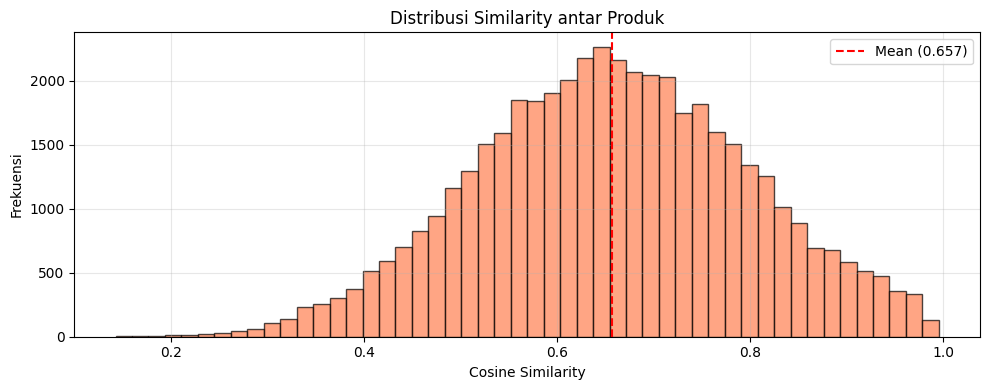


CONTOH SIMILARITY (3 produk)
--------------------------------------------------

Produk 1: Avoskin Your Skin Bae Vitamin C 3% + Nia (AVOSKIN)
   Top 5 produk serupa:
   1. [0.732] Scarlett Peeling So Good Brightenin (SCARLETT)
   2. [0.716] Scarlett Glowtening Serum (SCARLETT)
   3. [0.696] The Originote Retinol Serum (ORIGINOTE)
   4. [0.694] Wardah Nature Daily Aloe Hydramild  (WARDAH)
   5. [0.692] Wardah Nature Daily Mineral+ Clarif (WARDAH)

Produk 2: Avoskin Ultra Brightening Cream (AVOSKIN)
   Top 5 produk serupa:
   1. [0.856] Avoskin Perfect Hydrating Treatment (AVOSKIN)
   2. [0.840] Wardah White Secret Exfoliating Scr (WARDAH)
   3. [0.823] Scarlett Whitening Acne Night Cream (SCARLETT)
   4. [0.795] Scarlett Peeling So Good Brightenin (SCARLETT)
   5. [0.795] Wardah Cica Complex Panthenol Hydra (WARDAH)

Produk 3: Avoskin Your Skin Bae Alpha Arbutin + Gr (AVOSKIN)
   Top 5 produk serupa:
   1. [0.916] Avoskin Your Skin Bae Ultimate Hyal (AVOSKIN)
   2. [0.914] The Originot

In [20]:

from sklearn.metrics.pairwise import cosine_similarity

print('EKSTRAKSI PRODUCT EMBEDDINGS')
print('-' * 50)


print('Generating embeddings...')
product_embeddings = model.predict(padded, verbose=0)

print(f'Shape: {product_embeddings.shape}')
print(f'   - {product_embeddings.shape[0]:,} produk')
print(f'   - {product_embeddings.shape[1]} dimensi embedding')


print('\nComputing cosine similarity matrix...')
similarity_matrix = cosine_similarity(product_embeddings)

print(f'Similarity matrix: {similarity_matrix.shape}')

print('\nSTATISTIK SIMILARITY')
print('-' * 50)

mask = ~np.eye(similarity_matrix.shape[0], dtype=bool)
similarities = similarity_matrix[mask]

print(f'Mean similarity   : {similarities.mean():.4f}')
print(f'Std similarity    : {similarities.std():.4f}')
print(f'Min similarity    : {similarities.min():.4f}')
print(f'Max similarity    : {similarities.max():.4f}')

print('\nDistribusi Similarity Scores:')
plt.figure(figsize=(10, 4))
plt.hist(similarities, bins=50, color='coral', edgecolor='black', alpha=0.7)
plt.axvline(similarities.mean(), color='red', linestyle='--', 
            label=f'Mean ({similarities.mean():.3f})')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frekuensi')
plt.title('Distribusi Similarity antar Produk')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('\nCONTOH SIMILARITY (3 produk)')
print('-' * 50)

for idx in range(min(3, len(df))):

    sim_scores = list(enumerate(similarity_matrix[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:6]
    
    brand = df.iloc[idx]['brand'].upper() if 'brand' in df.columns else ''
    print(f'\nProduk {idx+1}: {df.iloc[idx]["product_name"][:40]} ({brand})')
    print('   Top 5 produk serupa:')
    
    for i, (prod_idx, score) in enumerate(sim_scores, 1):
        similar_brand = df.iloc[prod_idx]['brand'].upper() if 'brand' in df.columns else ''
        print(f'   {i}. [{score:.3f}] {df.iloc[prod_idx]["product_name"][:35]} ({similar_brand})')

print('\nEMBEDDINGS SELESAI')
print('Variabel tersedia:')
print(f'   - model: Neural Network model')
print(f'   - product_embeddings: {product_embeddings.shape} array')
print(f'   - similarity_matrix: {similarity_matrix.shape} array')
print('\nSelanjutnya: Build fungsi rekomendasi produk')

## Sistem Rekomendasi Produk Skincare

Membangun fungsi rekomendasi dengan berbagai filter (brand, skin type, product type).

In [8]:

def recommend_products(product_name=None, product_idx=None, top_n=10, 
                      filter_brand=None, filter_skin_type=None, filter_product_type=None,
                      same_brand_only=False, different_brand_only=False):
 
    

    if product_idx is None and product_name is None:
        return "Berikan product_name atau product_idx"

    if product_name is not None:
        matches = df[df['product_name'].str.contains(product_name, case=False, na=False)]
        if len(matches) == 0:
            return f"Produk '{product_name}' tidak ditemukan"
        elif len(matches) > 1:
            print(f"Ditemukan {len(matches)} produk yang cocok:")
            for i, row in matches.head(5).iterrows():
                print(f"   [{i}] {row['product_name']} - {row['brand'].upper()}")
            return "Gunakan product_idx=[index] untuk memilih produk spesifik"
        else:
            product_idx = matches.index[0]

    if product_idx >= len(df):
        return f"Index {product_idx} tidak valid (max: {len(df)-1})"
    

    target_product = df.iloc[product_idx]
    target_brand = target_product['brand']
    
    print('REKOMENDASI PRODUK SKINCARE')
    print('-' * 50)
    print('Produk Target:')
    print(f'   Nama        : {target_product["product_name"]}')
    print(f'   Brand       : {target_brand.upper()}')
    if 'product_type' in df.columns:
        print(f'   Type        : {target_product.get("product_type", "N/A")}')
    if 'skin_type' in df.columns:
        print(f'   Skin Type   : {target_product.get("skin_type", "N/A")}')
    print('-' * 50)
    

    sim_scores = list(enumerate(similarity_matrix[product_idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    recommendations = []
    for idx, score in sim_scores[1:]: 
        product = df.iloc[idx]
        
        # Apply filters
        if same_brand_only and product['brand'] != target_brand:
            continue
        if different_brand_only and product['brand'] == target_brand:
            continue
        if filter_brand and product['brand'] != filter_brand:
            continue
        if filter_skin_type and 'skin_type' in df.columns:
            if product.get('skin_type', '') != filter_skin_type:
                continue
        if filter_product_type and 'product_type' in df.columns:
            if product.get('product_type', '') != filter_product_type:
                continue
        
        recommendations.append({
            'index': idx,
            'similarity': score,
            'product_name': product['product_name'],
            'brand': product['brand'],
            'product_type': product.get('product_type', 'N/A'),
            'skin_type': product.get('skin_type', 'N/A'),
            'active_ingredients': product.get('active_ingredients', 'N/A')[:50] + '...',
            'benefits': product.get('benefits', 'N/A')[:50] + '...'
        })
        
        if len(recommendations) >= top_n:
            break
    
    rec_df = pd.DataFrame(recommendations)

    if len(rec_df) == 0:
        print('\nTidak ada rekomendasi yang sesuai dengan filter')
        return None
    
    print(f'\nTop {len(rec_df)} Rekomendasi:')
    print('-' * 50)
    
    for i, row in rec_df.iterrows():
        print(f"\n{i+1}. [{row['similarity']:.3f}] {row['product_name']}")
        print(f"   Brand       : {row['brand'].upper()}")
        print(f"   Type        : {row['product_type']}")
        print(f"   Skin Type   : {row['skin_type']}")
        print(f"   Ingredients : {row['active_ingredients']}")
        print(f"   Benefits    : {row['benefits']}")
    
    return rec_df

print('Fungsi recommend_products() siap digunakan!')
print('\nContoh penggunaan:')
print('   recommend_products(product_name="niacinamide", top_n=5)')
print('   recommend_products(product_idx=0, top_n=10)')
print('   recommend_products(product_idx=0, filter_skin_type="oily")')
print('   recommend_products(product_idx=0, same_brand_only=True)')
print('   recommend_products(product_idx=0, different_brand_only=True)')

Fungsi recommend_products() siap digunakan!

Contoh penggunaan:
   recommend_products(product_name="niacinamide", top_n=5)
   recommend_products(product_idx=0, top_n=10)
   recommend_products(product_idx=0, filter_skin_type="oily")
   recommend_products(product_idx=0, same_brand_only=True)
   recommend_products(product_idx=0, different_brand_only=True)


## Testing dam Evaluasi Sistem Rekomendasi

Uji coba rekomendasi dengan berbagai skenario dan analisis kualitas.

In [9]:

print('🧪 TESTING SISTEM REKOMENDASI')
print('=' * 80)


print('\n📌 TEST 1: Rekomendasi Umum (Top 5)')
print('─' * 80)
rec1 = recommend_products(product_idx=0, top_n=5)


print('\n\n📌 TEST 2: Filter berdasarkan Skin Type')
print('─' * 80)
if 'skin_type' in df.columns and df.iloc[0].get('skin_type'):
    target_skin = df.iloc[0]['skin_type']
    rec2 = recommend_products(product_idx=0, top_n=5, filter_skin_type=target_skin)
else:
    print('⚠️  Kolom skin_type tidak tersedia atau kosong')


print('\n\n📌 TEST 3: Same Brand Only')
print('─' * 80)
rec3 = recommend_products(product_idx=0, top_n=5, same_brand_only=True)

print('\n\n📌 TEST 4: Different Brand Only')
print('─' * 80)
rec4 = recommend_products(product_idx=0, top_n=5, different_brand_only=True)

print('\n\n📊 ANALISIS KUALITAS REKOMENDASI')
print('=' * 80)

if rec1 is not None and len(rec1) > 0:
    print(f'Similarity Score Statistics:')
    print(f'   Mean    : {rec1["similarity"].mean():.4f}')
    print(f'   Std     : {rec1["similarity"].std():.4f}')
    print(f'   Min     : {rec1["similarity"].min():.4f}')
    print(f'   Max     : {rec1["similarity"].max():.4f}')
    
    # Analisis brand diversity
    if 'brand' in rec1.columns:
        brand_counts = rec1['brand'].value_counts()
        print(f'\nBrand Diversity:')
        for brand, count in brand_counts.items():
            print(f'   {brand:<15} : {count} produk')

print('\n' + '=' * 80)
print('✅ TESTING SELESAI!')
print('=' * 80)

🧪 TESTING SISTEM REKOMENDASI

📌 TEST 1: Rekomendasi Umum (Top 5)
────────────────────────────────────────────────────────────────────────────────
REKOMENDASI PRODUK SKINCARE
--------------------------------------------------
Produk Target:
   Nama        : Avoskin Your Skin Bae Vitamin C 3% + Niacinamide 2% + Mandarin Orange Fruit Extract Serum
   Brand       : AVOSKIN
   Type        : Serum
   Skin Type   : Semua Jenis Kulit, 
Kusam
--------------------------------------------------

Top 5 Rekomendasi:
--------------------------------------------------

1. [0.862] Emina Oat Amino Ceramide Barrier Low pH Gel Cleanser 
   Brand       : EMINA
   Type        : Cleanser
   Skin Type   : Semua Jenis Kulit
   Ingredients : Glycerin, Trehalose, Allantoin, Beta-Glucan, Sodiu...
   Benefits    : Perbaiki skin barrier kulit, Kontrol minyak sebum ...

2. [0.764] Avoskin The Great Shield Sunscreen SPF 50 PA++++
   Brand       : AVOSKIN
   Type        : Sunscreen
   Skin Type   : Normal, Kering, ku

📊 PERBANDINGAN REKOMENDASI ANTAR BRAND
Total brand: 8

🔍 Sample produk per brand:
   avoskin         : [  0] Avoskin Your Skin Bae Vitamin C 3% + Nia
   emina           : [ 30] Emina Sun Battle SPF 35 Pa+++
   glad2glow       : [ 60] Glad2Glow Berry Peptide Eye Cream
   originote       : [135] The Originote Ceratinol Moisturizer
   scarlett        : [ 85] Scarlett Brightly Essence Toner
   somethinc       : [110] Somethinc Acne Shot AC Overnight Treatme
   wardah          : [160] Wardah Renew You Anti-aging Night Cream
   whitelab        : [190] Whitelab A-dose+ Glowing Serum
REKOMENDASI PRODUK SKINCARE
--------------------------------------------------
Produk Target:
   Nama        : Avoskin Your Skin Bae Vitamin C 3% + Niacinamide 2% + Mandarin Orange Fruit Extract Serum
   Brand       : AVOSKIN
   Type        : Serum
   Skin Type   : Semua Jenis Kulit, 
Kusam
--------------------------------------------------

Top 10 Rekomendasi:
--------------------------------------------------

1

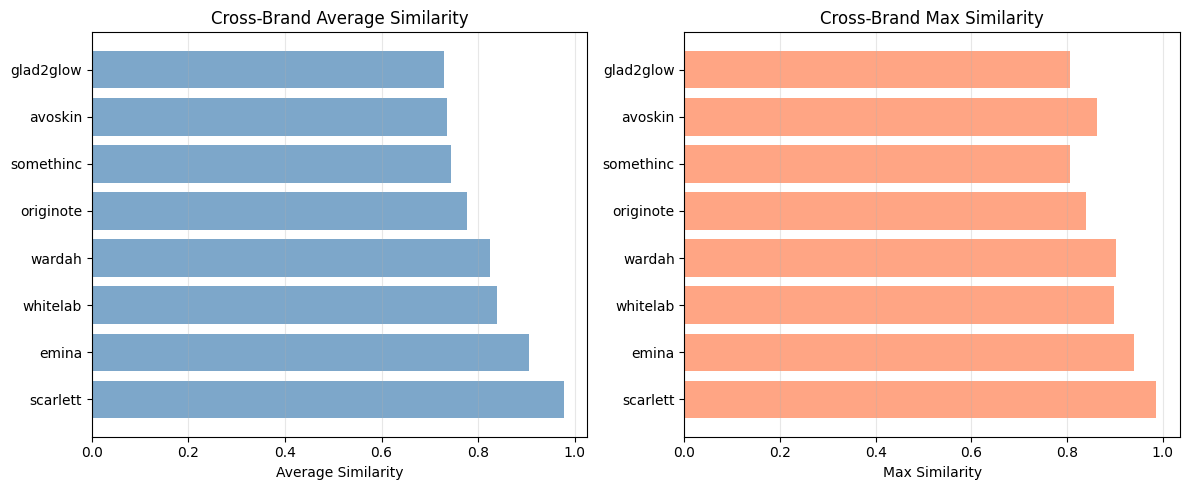

In [10]:

print('📊 PERBANDINGAN REKOMENDASI ANTAR BRAND')
print('=' * 80)

sample_products = df.groupby('brand').first().reset_index()

print(f'Total brand: {len(sample_products)}')
print('\n🔍 Sample produk per brand:')
for i, row in sample_products.iterrows():
    idx = df[df['product_name'] == row['product_name']].index[0]
    print(f"   {row['brand']:<15} : [{idx:3d}] {row['product_name'][:40]}")


cross_brand_sim = []
for i, row in sample_products.iterrows():
    brand = row['brand']
    idx = df[df['product_name'] == row['product_name']].index[0]
    

    rec = recommend_products(product_idx=idx, top_n=10, different_brand_only=True)
    
    if rec is not None and len(rec) > 0:
        avg_sim = rec['similarity'].mean()
        max_sim = rec['similarity'].max()
        cross_brand_sim.append({
            'brand': brand,
            'avg_similarity': avg_sim,
            'max_similarity': max_sim,
            'num_recommendations': len(rec)
        })

cb_df = pd.DataFrame(cross_brand_sim)
if len(cb_df) > 0:
    cb_df = cb_df.sort_values('avg_similarity', ascending=False)
    
    print('\nBrand dengan similarity tertinggi ke brand lain:')
    for i, row in cb_df.iterrows():
        print(f"   {row['brand']:<15} : Avg={row['avg_similarity']:.3f}, Max={row['max_similarity']:.3f}")

    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.barh(cb_df['brand'], cb_df['avg_similarity'], color='steelblue', alpha=0.7)
    plt.xlabel('Average Similarity')
    plt.title('Cross-Brand Average Similarity')
    plt.grid(axis='x', alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.barh(cb_df['brand'], cb_df['max_similarity'], color='coral', alpha=0.7)
    plt.xlabel('Max Similarity')
    plt.title('Cross-Brand Max Similarity')
    plt.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()



In [12]:

recommend_products(product_name="niacinamide", top_n=5)

recommend_products(product_idx=0, same_brand_only=True)

Ditemukan 6 produk yang cocok:
   [0] Avoskin Your Skin Bae Vitamin C 3% + Niacinamide 2% + Mandarin Orange Fruit Extract Serum - AVOSKIN
   [3] Avoskin Your Skin Bae Niacinamide 12% + Centella Asiatica
 - AVOSKIN
   [53] Scarlett Whitening Niacinamide Serum - SCARLETT
   [65] Somethinc 10% Niacinamide Barrier Serum - SOMETHINC
   [75] Niacinamide + Moisture Beet Serum - SOMETHINC
REKOMENDASI PRODUK SKINCARE
--------------------------------------------------
Produk Target:
   Nama        : Avoskin Your Skin Bae Vitamin C 3% + Niacinamide 2% + Mandarin Orange Fruit Extract Serum
   Brand       : AVOSKIN
   Type        : Serum
   Skin Type   : Semua Jenis Kulit, 
Kusam
--------------------------------------------------

Top 10 Rekomendasi:
--------------------------------------------------

1. [0.861] Avoskin Miraculous Divine Aura Toner-essence
   Brand       : AVOSKIN
   Type        : Toner
   Skin Type   : Kusam, Kering, Berminyak, sensitif
   Ingredients : Niacinamide, 3-O-Ethyl Asco

,index,similarity,product_name,brand,product_type,skin_type,active_ingredients,benefits
0,9,0.861295,Avoskin Miraculous Divine Aura Toner-essence,avoskin,Toner,"Kusam, Kering, Berminyak, sensitif","Niacinamide, 3-O-Ethyl Ascorbic Acid, Zinc PCA...","membantu mencerahkan warna kulit, mengurangi t..."
1,8,0.819864,Avoskin Miraculous Refining Series AHA BHA PHA...,avoskin,Mask,"Berminyak, acne prone, kusam, sensitif, kering","Glycolic Acid, Gluconolactone, Salicylic Acid,...",Memberikan sensasi melembapkan dan bekerja efe...
2,11,0.733953,Avoskin Your Skin Bae Serum Tea Tree + Witch H...,avoskin,Serum,"berminyak, sensitif, kusam","Niacinamide (2%), Glycolic Acid (0.5%), Hamame...","merawat elastisitas kulit, menjaga kelembapan ..."
3,12,0.708452,Avoskin Miraculous Dark Spots Solution Ampoule,avoskin,Ampoule,"hiperpigmentasi, kusam, kombinasi, berminyak, ...","Niacinamide (5%), Tranexamic Acid (2%), Glycol...",Mengurangi penampilan noda hitam dan hiperpigm...
4,3,0.703633,Avoskin Your Skin Bae Niacinamide 12% + Centel...,avoskin,Serum,"Sensitif, kering, kusam","Niacinamide, Glycerin, Butylene Glycol, Biosac...","menjaga kulit cerah maksimal, terhidrasi, terh..."
5,10,0.699939,Avoskin Your Skin Bae Ultimate Hyaluron Marine...,avoskin,Toner,"kering, sensitif, kusam","Hydrolyzed Collagen Extract, Galactomyces Ferm...",memberikan efek hidrasi optimal pada kulit ser...
6,13,0.677984,Avoskin Miraculous Acne Solution Overnight Liq...,avoskin,Mask,"Kombinasi, berminyak, kusam, sensitif","Niacinamide, Salicylic Acid, Carica Papaya Fru...","merawat kulit berjerawat, menyamarkan pori-por..."
7,6,0.676256,Toner Avoskin Perfect Hydrating Treatment Essence,avoskin,Toner,"kusam, sensitif, kering","Ethyl Ascorbic Acid, Propylene Glycol, Glyceri...","membuat kulit terasa lebih lembut dan kenyal, ..."
8,4,0.639657,Avoskin Intensive Nourishing Eye Cream\n,avoskin,Eye cream,"kering, sensitif, kusam","Ethylhexyl Olivate, PEG-4 Olivate, Phytosteryl...",Melembapkan kulit di sekitar mata sehingga dap...
9,5,0.629158,Avoskin Aloe Vera Facial Wash,avoskin,Cleanser,"Normal, Kering","Sodium Cocoyl Alaninate, Sodium Laureth Sulfat...",mampu mengangkat sel kulit mati hingga lapisan...


In [21]:

from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

print('TRAINING BRAND CLASSIFICATION MODEL')
print('=' * 80)

le = LabelEncoder()
brand_labels = le.fit_transform(df['brand'])
brand_labels_cat = to_categorical(brand_labels)

print(f'Number of brands: {len(le.classes_)}')
print(f'Brands: {le.classes_}')

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    padded, brand_labels_cat, 
    test_size=0.2, 
    random_state=42,
    stratify=brand_labels
)

print(f'\nTraining set: {X_train.shape[0]} samples')
print(f'Validation set: {X_val.shape[0]} samples')

from tensorflow.keras.layers import Input, Embedding, GlobalAveragePooling1D, Dense, Dropout

input_layer = Input(shape=(max_length,))
embedding = Embedding(vocab_size, 128, input_length=max_length)(input_layer)
pooling = GlobalAveragePooling1D()(embedding)
dense1 = Dense(64, activation='relu')(pooling)
dropout1 = Dropout(0.3)(dense1)

embedding_layer = Dense(32, activation='relu', name='product_embedding')(dropout1)


dropout2 = Dropout(0.3)(embedding_layer)
output = Dense(len(le.classes_), activation='softmax', name='brand_output')(dropout2)


model = Model(inputs=input_layer, outputs=output)
model.compile(
    optimizer=Adam(0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('\nModel Architecture:')
model.summary()

print('\nTraining...')
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)



TRAINING BRAND CLASSIFICATION MODEL
Number of brands: 8
Brands: ['avoskin' 'emina' 'glad2glow' 'originote' 'scarlett' 'somethinc' 'wardah'
 'whitelab']

Training set: 172 samples
Validation set: 43 samples

Model Architecture:


c:\Users\Naufal\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 50, 128)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ product_embedding (Dense)       │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ brand_output (Dense)            │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 650,600 (2.48 MB)

 Trainable params: 650,600 (2.48 MB)

 Non-trainable params: 0 (0.00 B)


Training...
Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.1163 - loss: 2.0780 - val_accuracy: 0.2093 - val_loss: 2.0730
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.1163 - loss: 2.0780 - val_accuracy: 0.2093 - val_loss: 2.0730
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1919 - loss: 2.0666 - val_accuracy: 0.2326 - val_loss: 2.0646
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1919 - loss: 2.0666 - val_accuracy: 0.2326 - val_loss: 2.0646
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3198 - loss: 2.0475 - val_accuracy: 0.2791 - val_loss: 2.0529
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3198 - loss: 2.0475 - val_accuracy: 0.2791 - val_loss: 2.0529
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3547 - loss: 2.0274 - val_accuracy: 0.2326 - val_loss: 2.0343
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3547 - loss: 2.0274 - val_accuracy: 0.232

BEST EPOCH: 100
Train Loss     : 0.0240
Train Acc      : 0.9942 (99.42%)
Val Loss       : 0.1291
Val Acc        : 0.9767 (97.67%)


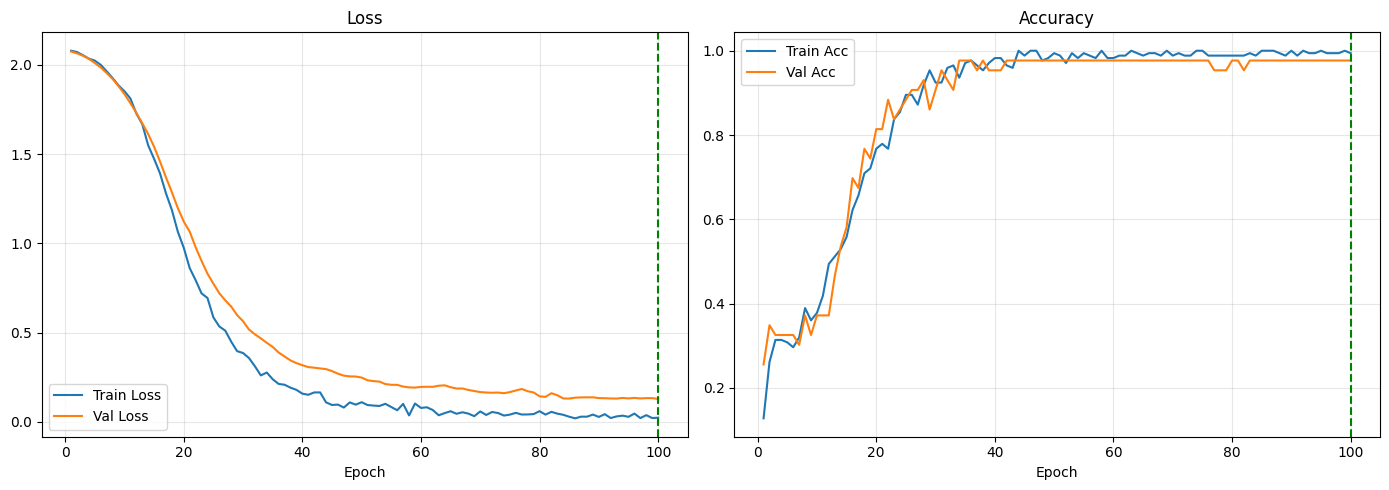

In [12]:
import numpy as np
import matplotlib.pyplot as plt



hist = history.history
train_loss, val_loss = hist['loss'], hist['val_loss']
train_acc, val_acc = hist['accuracy'], hist['val_accuracy']
epochs = range(1, len(train_loss) + 1)


best = np.argmin(val_loss)
best_epoch = best + 1

print(f"BEST EPOCH: {best_epoch}")
print(f"Train Loss     : {train_loss[best]:.4f}")
print(f"Train Acc      : {train_acc[best]:.4f} ({train_acc[best]*100:.2f}%)")
print(f"Val Loss       : {val_loss[best]:.4f}")
print(f"Val Acc        : {val_acc[best]:.4f} ({val_acc[best]*100:.2f}%)")


plt.figure(figsize=(14, 5))


plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Val Loss')
plt.axvline(best_epoch, color='green', linestyle='--')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(alpha=0.3)


plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc, label='Train Acc')
plt.plot(epochs, val_acc, label='Val Acc')
plt.axvline(best_epoch, color='green', linestyle='--')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()



EVALUASI MODEL BRAND CLASSIFICATION
Final Validation Accuracy: 0.9767 (97.67%)

Classification Report:
              precision    recall  f1-score   support

     avoskin       1.00      1.00      1.00         6
       emina       1.00      1.00      1.00         6
   glad2glow       1.00      0.80      0.89         5
   originote       1.00      1.00      1.00         5
    scarlett       0.83      1.00      0.91         5
   somethinc       1.00      1.00      1.00         5
      wardah       1.00      1.00      1.00         6
    whitelab       1.00      1.00      1.00         5

    accuracy                           0.98        43
   macro avg       0.98      0.97      0.97        43
weighted avg       0.98      0.98      0.98        43



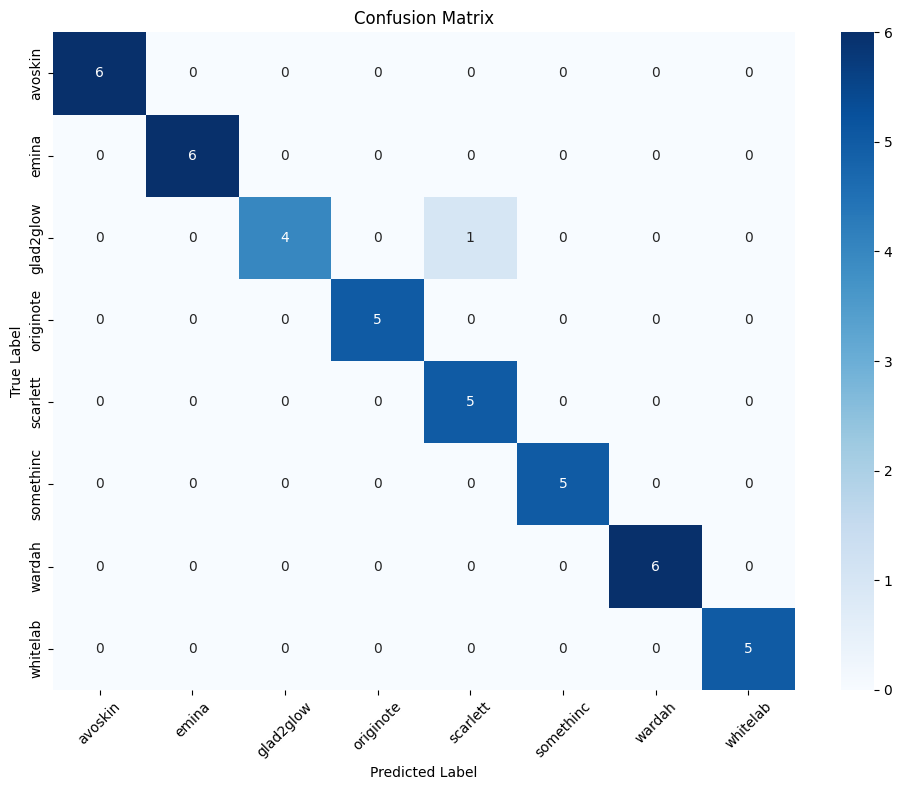


Per-Brand Accuracy:
avoskin        : 1.000 (100.0%)
emina          : 1.000 (100.0%)
glad2glow      : 0.800 (80.0%)
originote      : 1.000 (100.0%)
scarlett       : 1.000 (100.0%)
somethinc      : 1.000 (100.0%)
wardah         : 1.000 (100.0%)
whitelab       : 1.000 (100.0%)

Training Summary:
Best Epoch     : 100
Best Val Loss  : 0.1291
Best Val Acc   : 0.9767 (97.67%)
Final Train Acc: 0.9942 (99.42%)

Model Complexity:
Total Parameters     : 650,600
Trainable Parameters : 650,600

Evaluasi selesai.
Akurasi akhir: 97.67%


In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print("EVALUASI MODEL BRAND CLASSIFICATION")
print("=" * 70)

# Prediksi pada validation set
y_pred = model.predict(X_val, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_val, axis=1)

# Akurasi final
final_accuracy = np.mean(y_pred_classes == y_true_classes)
print(f"Final Validation Accuracy: {final_accuracy:.4f} ({final_accuracy*100:.2f}%)")

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_true_classes, 
    y_pred_classes, 
    target_names=le.classes_,
    zero_division=0
))

# Confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Akurasi per brand
print("\nPer-Brand Accuracy:")
for i, brand in enumerate(le.classes_):
    mask = (y_true_classes == i)
    count = np.sum(mask)
    if count > 0:
        acc = np.mean(y_pred_classes[mask] == y_true_classes[mask])
        print(f"{brand:<15}: {acc:.3f} ({acc*100:.1f}%)")

# Ringkasan training history
best_epoch = np.argmin(val_loss) + 1
print("\nTraining Summary:")
print(f"Best Epoch     : {best_epoch}")
print(f"Best Val Loss  : {min(val_loss):.4f}")
print(f"Best Val Acc   : {max(val_acc):.4f} ({max(val_acc)*100:.2f}%)")
print(f"Final Train Acc: {train_acc[-1]:.4f} ({train_acc[-1]*100:.2f}%)")

# Model complexity
total_params = model.count_params()
trainable_params = np.sum([np.prod(v.shape) for v in model.trainable_weights])

print("\nModel Complexity:")
print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")

print("\nEvaluasi selesai.")
print(f"Akurasi akhir: {final_accuracy*100:.2f}%")
print("=" * 70)


In [22]:

embedding_extractor = Model(
    inputs=model.input,
    outputs=model.get_layer('product_embedding').output
)

product_embeddings = embedding_extractor.predict(padded, verbose=0)
print(f'\nEmbeddings extracted: {product_embeddings.shape}')


Embeddings extracted: (215, 32)


## 🚀 Export Data untuk Streamlit Deployment

Menyimpan model dan data yang dibutuhkan untuk deployment aplikasi Streamlit.

In [23]:
import pickle
import os

# Buat folder untuk menyimpan model dan data
os.makedirs('deployment_files', exist_ok=True)

# 1. Simpan model
model.save('deployment_files/skincare_model.h5')
print("Model saved successfully")

# 2. Simpan embedding extractor
embedding_extractor.save('deployment_files/embedding_model.h5')
print("Embedding model saved successfully")

# 3. Simpan product embeddings
np.save('deployment_files/product_embeddings.npy', product_embeddings)
print("Product embeddings saved successfully")

# 4. Simpan similarity matrix
np.save('deployment_files/similarity_matrix.npy', similarity_matrix)
print("Similarity matrix saved successfully")

# 5. Simpan dataframe
df.to_csv('deployment_files/skincare_products.csv', index=False)
print("Product data saved successfully")

# 6. Simpan tokenizer
with open('deployment_files/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("Tokenizer saved successfully")

# 7. Simpan label encoder
with open('deployment_files/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print("Label encoder saved successfully")

print("\nSemua file berhasil disimpan di folder 'deployment_files'")
print(f"Total files: {len(os.listdir('deployment_files'))}")

Model saved successfully
Embedding model saved successfully
Product embeddings saved successfully
Similarity matrix saved successfully
Product data saved successfully
Tokenizer saved successfully
Label encoder saved successfully

Semua file berhasil disimpan di folder 'deployment_files'
Total files: 7
